# Cardiac Patient Monitoring System

This project develops a supervised machine learning classification system
for predicting heart disease using synthetic cardiovascular and health-related data.

The project includes:
- Data inspection and cleaning
- Exploratory Data Analysis (EDA)
- Statistical analysis
- Feature analysis
- Train/Validation/Test methodology
- Feature engineering
- Supervised learning
- Cross-validation
- Model comparison
- Pipeline construction
- Final evaluation
- Error analysis





## Explaining the Problem

>Cardiovascular diseases are an important health concern, and identifying patients who may be at higher risk can support earlier medical attention and better decision-making.
>
>In this project, the main problem is to use patient health and clinical information to predict whether a patient is likely to have a cardiac condition. The dataset contains different patient characteristics and medical measurements that may be related to cardiac disease.
>
>The machine learning task is therefore formulated as a binary classification problem, where the model predicts one of two possible outcomes: the patient is classified as having a cardiac condition or not.
>
>The main challenge is that different patient characteristics may interact with each other, and some variables may have stronger predictive value than others. Therefore, the project investigates the data, analyzes relationships between variables, prepares the features, and compares different machine learning approaches to determine which model provides better predictive performance.
>
>The project also evaluates whether feature engineering can improve the model by creating meaningful additional features from the available patient information.
>
>The final goal is not simply to obtain a high accuracy score, but to understand which factors contribute to the prediction, how well the models distinguish between the two classes, and whether the proposed improvements actually make the model better.

## Problem Statement

>How can patient health and clinical characteristics be used to predict the presence of a cardiac condition, and can feature engineering improve the performance of machine learning models for this classification task?

## 0. Import Libraries and Define Project Settings

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report,roc_curve

from src.evaluate import evaluate_model
from src.engineered_features import add_engineered_features
RANDOM_STATE = 42

### What this code does

This cell imports every library and function needed for the complete machine-learning workflow.

- `numpy` provides numerical operations.
- `pandas` is used to load, inspect, transform, and compare tabular data.
- `matplotlib.pyplot` and `seaborn` create the visualizations.
- `train_test_split` creates the train, validation, and test sets.
- `cross_validate` and `StratifiedKFold` support cross-validation and stable model evaluation.
- `ColumnTransformer` lets the notebook apply different preprocessing to numerical and categorical columns.
- `Pipeline` keeps preprocessing and model training together, which helps prevent data leakage.
- `SimpleImputer` fills missing values when needed.
- `StandardScaler` standardizes numerical variables.
- `OneHotEncoder` converts categorical values into numerical indicator features.
- `LogisticRegression` is the baseline linear classifier.
- `RandomForestClassifier` is the comparison model and the final selected model.
- `confusion_matrix`, `classification_report`, and `roc_curve` provide detailed classification evaluation.
- `evaluate_model` is a project-specific evaluation function that returns Accuracy, Precision, Recall, F1, and ROC-AUC.
- `add_engineered_features` is a project-specific function that creates additional numerical features.

`RANDOM_STATE = 42` fixes the random behavior used by the data split and models so the experiment is reproducible.

### Why this matters

The notebook is not only training a model. It is building a complete reproducible workflow: data preparation → exploration → preprocessing → model training → validation → cross-validation → feature engineering → final test evaluation → model and result export.

## 1.1 Load the Dataset

In [2]:
df=pd.read_csv("C:/Users/pc/Desktop/inter/Cardiac_Patient_Monitoring/data/heart (1).csv")
df.head()

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (918, 12)


### What this code does

`pd.read_csv()` loads the heart-disease dataset into a pandas DataFrame named `df`.

`df.head()` displays the first rows so the data can be visually checked.

`df.shape` returns the number of rows and columns.

### Result

The dataset contains **918 rows and 12 columns**.

The 12 columns include 11 input features and the target `Heart_Disease`.

### Why this matters

Before any machine-learning step, we need to confirm that the expected dataset was loaded and that its dimensions are reasonable. The 918 × 12 shape becomes the starting point for every later calculation.

## 1.2 Inspect Dataset Structure

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  Heart_Disease   918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


### What this code does

`df.info()` gives a structural summary of the DataFrame.

It reports:

- the number of observations,
- every column name,
- the number of non-null values,
- each column's data type,
- and an estimate of memory usage.

### Result interpretation

All **918 rows are non-null in every column**, so the dataset does not contain missing values according to this inspection.

There are:

- 6 numerical integer variables,
- 1 numerical floating-point variable,
- 5 categorical/string variables.

The target `Heart_Disease` is an integer with two classes.

### Why this matters

The data types determine how preprocessing must work. Numerical variables can be imputed and scaled, while categorical variables must be encoded before they can be used by the classifiers.

## 2.1 Build the Data Dictionary

In [4]:
data_dictionary = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})

data_dictionary

,Feature,Data Type,Missing Values,Unique Values
0,Age,int64,0,50
1,Sex,str,0,2
2,ChestPainType,str,0,4
3,RestingBP,int64,0,67
4,Cholesterol,int64,0,222
5,FastingBS,int64,0,2
6,RestingECG,str,0,3
7,MaxHR,int64,0,119
8,ExerciseAngina,str,0,2
9,Oldpeak,float64,0,53


### What this code does

This cell builds a compact data dictionary from the dataset.

For every column it records:

- `Feature`: the column name,
- `Data Type`: the pandas data type,
- `Missing Values`: the number of null values,
- `Unique Values`: the number of distinct values.

### Result interpretation

The table confirms that all 12 variables have **0 missing values**.

The target has 2 unique values, while the categorical predictors have between 2 and 4 categories. Numerical variables have many distinct values, as expected for measurements such as Age, Cholesterol, and MaxHR.

### Why this matters

A data dictionary gives a quick audit of the dataset and makes later preprocessing decisions transparent.

## 2.2 Handle Missing Values

In [5]:
df.fillna(df.mode().iloc[0], inplace=True)

df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
Heart_Disease     0
dtype: int64

### What this code does

`df.fillna(df.mode().iloc[0], inplace=True)` replaces missing values with the most frequent value of each column.

`df.isnull().sum()` checks whether any missing values remain.

### Result

The output is zero for every column.

Because the earlier inspection already showed no missing values, this operation does not materially change the dataset in this run.

### Important distinction

This is a general cleaning safeguard. Later, the machine-learning pipelines also contain separate imputers. That is useful because preprocessing inside a pipeline is applied consistently during training and validation.

### Why this matters

The goal is to make sure missing values cannot cause model-training failures. In this particular dataset, there were no missing values to repair.

## 2.3 Check for Duplicate Rows

In [6]:
duplicate_count = df.duplicated().sum()

print("Number of duplicated rows:", duplicate_count)

Number of duplicated rows: 0


### What this code does

`df.duplicated()` identifies rows that are exact duplicates.

`.sum()` counts how many duplicated rows exist.

### Result

The notebook reports:

**Number of duplicated rows: 0**

### Interpretation

No exact duplicate records were found, so no rows needed to be removed.

This is important because duplicated observations can give a model repeated evidence of the same patient pattern and may distort evaluation.

## 3.1 Descriptive Statistics for Numerical Variables

In [7]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Heart_Disease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


### What this code does

`df.describe()` calculates descriptive statistics for the numerical columns.

The main statistics are:

- `count`: number of observations,
- `mean`: arithmetic average,
- `std`: standard deviation,
- `min`: smallest value,
- `25%`: first quartile,
- `50%`: median,
- `75%`: third quartile,
- `max`: largest value.

### Key results

- Mean Age = **53.51**
- Mean RestingBP = **132.40**
- Mean Cholesterol = **198.80**
- Mean FastingBS = **0.233**
- Mean MaxHR = **136.81**
- Mean Oldpeak = **0.887**
- Mean Heart_Disease = **0.553**

The target mean is not a clinical measurement. Because the target is coded as 0 and 1, its mean of 0.553 corresponds to about **55.3% class 1**.

### What the ranges show

Age ranges from 28 to 77.

RestingBP ranges from 0 to 200.

Cholesterol ranges from 0 to 603.

MaxHR ranges from 60 to 202.

Oldpeak ranges from -2.6 to 6.2.

### Why this matters

Descriptive statistics reveal scale differences, spread, possible extreme values, and unusual values that should be understood before modeling.

## 3.2 Descriptive Statistics for Categorical Variables

In [8]:
df.describe(include="object")

C:\Users\pc\AppData\Local\Temp\ipykernel_24832\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
count,918,918,918,918,918
unique,2,4,3,2,3
top,M,ASY,Normal,N,Flat
freq,725,496,552,547,460


### What this code does

`df.describe(include="object")` summarizes the categorical variables.

It reports:

- `count`: number of observations,
- `unique`: number of distinct categories,
- `top`: the most frequent category,
- `freq`: how often that category occurs.

### Result interpretation

The most frequent categories are:

- `Sex`: **M**, 725 observations
- `ChestPainType`: **ASY**, 496 observations
- `RestingECG`: **Normal**, 552 observations
- `ExerciseAngina`: **N**, 547 observations
- `ST_Slope`: **Flat**, 460 observations

### Warning shown in the original output

Pandas produced a deprecation warning related to using `include="object"` with string dtypes. This warning does not mean the analysis failed; it indicates that future pandas versions prefer explicit string-dtype selection.

### Why this matters

Categorical variables cannot be fed directly into these models. Their categories are later converted into numerical one-hot encoded features.

## 4.1 Count Heart Disease Classes

In [9]:
target_counts = df["Heart_Disease"].value_counts()

print(target_counts)

Heart_Disease
1    508
0    410
Name: count, dtype: int64


### What this code does

`value_counts()` counts how many observations belong to each target class.

### Result

- `Heart_Disease = 1`: **508 patients**
- `Heart_Disease = 0`: **410 patients**

### Interpretation

There are more positive cases than negative cases, but the difference is not extreme.

This means the target is not perfectly balanced, so later evaluation should not rely on Accuracy alone. Recall, Precision, F1-score, and ROC-AUC are also important.

## 4.2 Calculate Target Class Percentages

In [10]:
target_percentages = df["Heart_Disease"].value_counts(normalize=True) * 100

print(target_percentages)

Heart_Disease
1    55.337691
0    44.662309
Name: proportion, dtype: float64


### What this code does

`value_counts(normalize=True)` converts class counts into proportions.

Multiplying by 100 converts those proportions into percentages.

### Result

- Heart disease = 1: **55.34%**
- No heart disease = 0: **44.66%**

### Interpretation

The two classes are reasonably close in size, although class 1 is the majority class.

The percentages explain why a model that simply favors the majority class would not be enough for this project: a useful classifier should correctly distinguish both classes.

## 4.3 Chart: Heart Disease Class Distribution

C:\Users\pc\AppData\Local\Temp\ipykernel_24832\4062472982.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


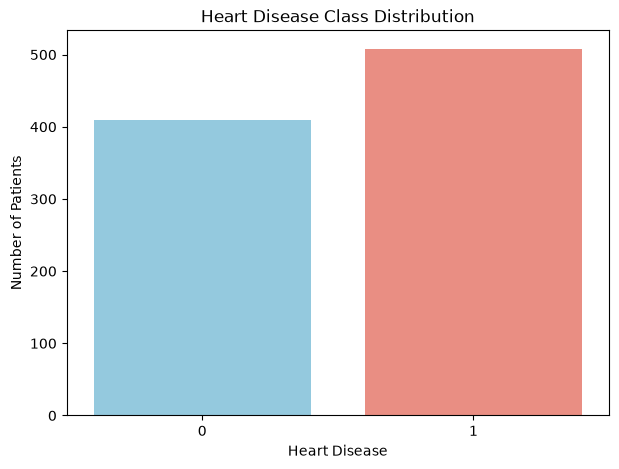

In [11]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Heart_Disease",
    palette=["skyblue", "salmon"]
)

plt.title("Heart Disease Class Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")
plt.savefig("C:/Users/pc/Desktop/inter/Cardiac_Patient_Monitoring/outputs/Heart-Disease-Class-Distribution.png")
plt.show()

### Chart: Heart Disease Class Distribution

This is a **count plot**.

- The x-axis contains the two target classes: 0 and 1.
- The y-axis shows the number of patients.
- The bar for class 0 represents the 410 patients without heart disease.
- The bar for class 1 represents the 508 patients with heart disease.

### What the chart tells us

The class-1 bar is taller than the class-0 bar, visually confirming the **55.34% vs 44.66%** distribution.

### Interpretation

The dataset has a moderate class imbalance, not an extreme one. This is why the notebook later evaluates multiple metrics instead of treating Accuracy as the only measure of performance.

## 5.1 Separate Numerical and Categorical Features

In [12]:

df_heart=df.drop(["Heart_Disease"],axis=1)
numeric_features = df_heart.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = df_heart.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

Categorical Features:
['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


C:\Users\pc\AppData\Local\Temp\ipykernel_24832\3715338361.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df_heart.select_dtypes(


### What this code does

The target column `Heart_Disease` is removed from `df` to create `df_heart`, because it should not be treated as an input feature.

Then `select_dtypes()` separates the remaining columns into:

**Numerical features**
- Age
- RestingBP
- Cholesterol
- FastingBS
- MaxHR
- Oldpeak

**Categorical features**
- Sex
- ChestPainType
- RestingECG
- ExerciseAngina
- ST_Slope

### Why this matters

The two groups require different preprocessing.

Numerical variables are later imputed and standardized.

Categorical variables are later imputed and one-hot encoded.

This separation is essential for constructing the `ColumnTransformer` used by both models.

## 5.2 Charts: Numerical Feature Distributions

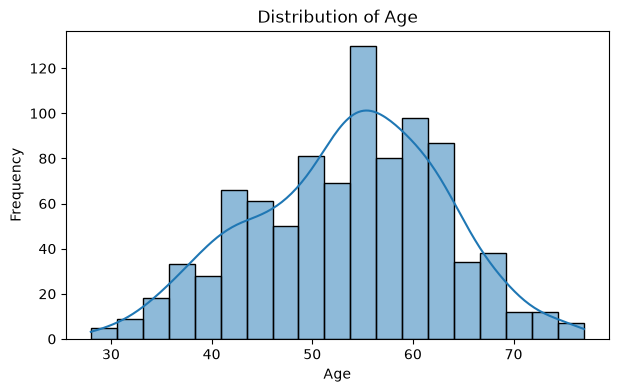

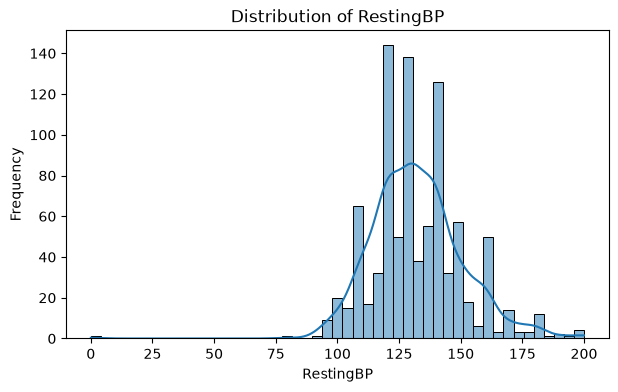

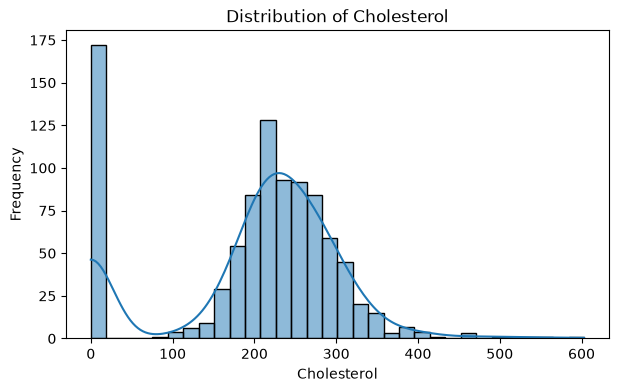

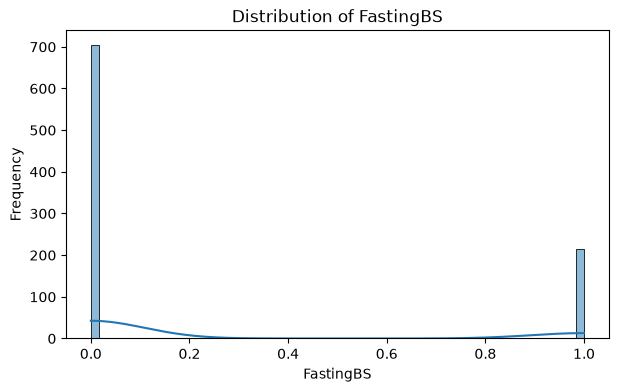

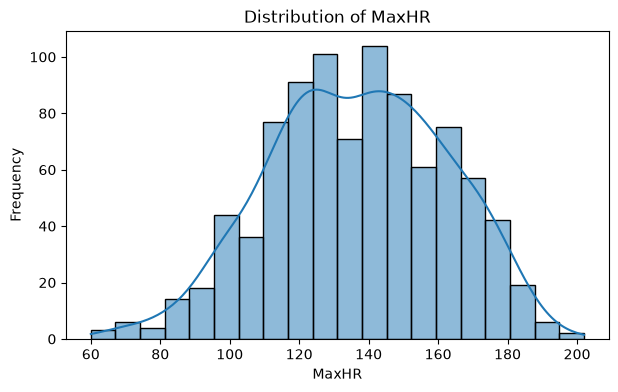

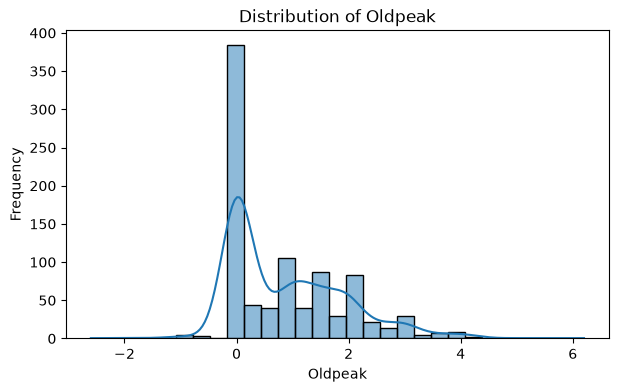

In [13]:
numeric_for_plot = [
    col for col in numeric_features 
]

for column in numeric_for_plot:
    plt.figure(figsize=(7, 4))
    sns.histplot(
        data=df,
        x=column,
        kde=True
    )
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.savefig(f"C:/Users/pc/Desktop/inter/Cardiac_Patient_Monitoring/outputs/Distribution-of-{column}.png")
    plt.show()

### Charts: Numerical Feature Distributions

This loop creates one **histogram with a KDE curve** for each numerical feature.

The six charts are:

1. **Distribution of Age**
2. **Distribution of RestingBP**
3. **Distribution of Cholesterol**
4. **Distribution of FastingBS**
5. **Distribution of MaxHR**
6. **Distribution of Oldpeak**

For every chart:

- the x-axis is the numerical feature,
- the y-axis is frequency,
- the bars show how many observations fall into each range,
- the KDE curve provides a smoothed view of the distribution.

### Chart 1 — Distribution of Age

The distribution is concentrated mainly between the 40s and 60s, with the highest frequencies around the 50s and 60s. Very young and very old observations are less frequent.

### Chart 2 — Distribution of RestingBP

Most observations are concentrated around roughly 100–160, with the highest frequencies around the 120–140 range. The plot also shows a long right tail toward values close to 200. The descriptive statistics report a minimum of 0, which is unusual for a blood-pressure measurement and should be treated cautiously in this synthetic dataset.

### Chart 3 — Distribution of Cholesterol

The chart has a very visible spike at **0**, followed by a broad main distribution centered roughly around 200–300. There is also a long right tail extending above 400 toward the maximum of 603. This is an important data-quality observation because zero cholesterol values are unusual in a real clinical setting.

### Chart 4 — Distribution of FastingBS

This is a binary variable, so the distribution is concentrated at 0 and 1 rather than forming a continuous shape. Class 0 is much more frequent, which is consistent with the dataset's descriptive results.

### Chart 5 — Distribution of MaxHR

The values form a broad, approximately bell-shaped distribution centered around the 130–150 range. The observations extend from about 60 to just above 200.

### Chart 6 — Distribution of Oldpeak

The distribution is strongly concentrated at **0**, with a smaller set of positive values extending toward about 6.2 and a few negative observations. This creates a clear right-skewed shape with a large spike at zero.

### Why these charts matter

These plots reveal concentration, spread, skewness, and unusual values before modeling. They also explain why preprocessing decisions such as scaling are useful, especially for Logistic Regression.

## 5.3 Charts: Categorical Feature Distributions

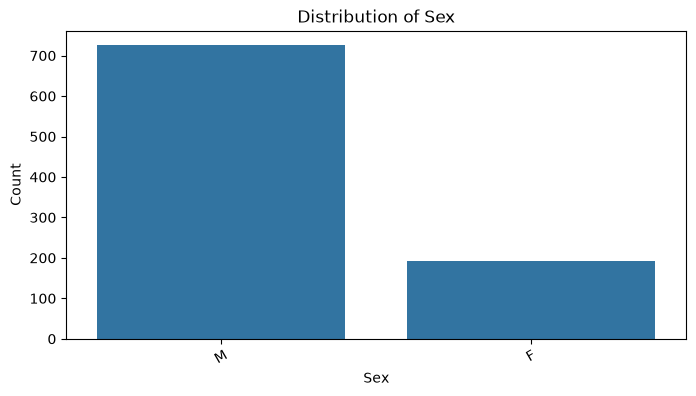

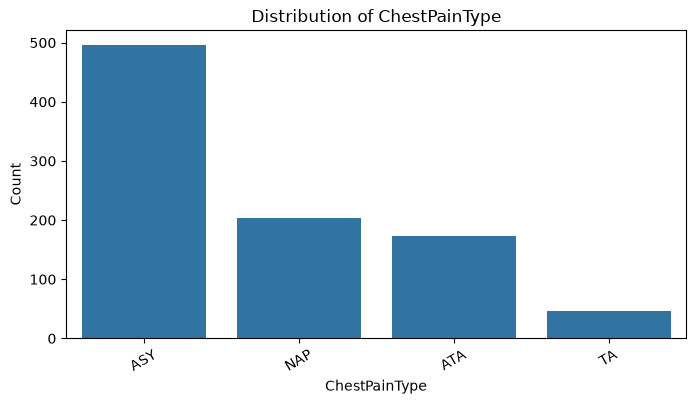

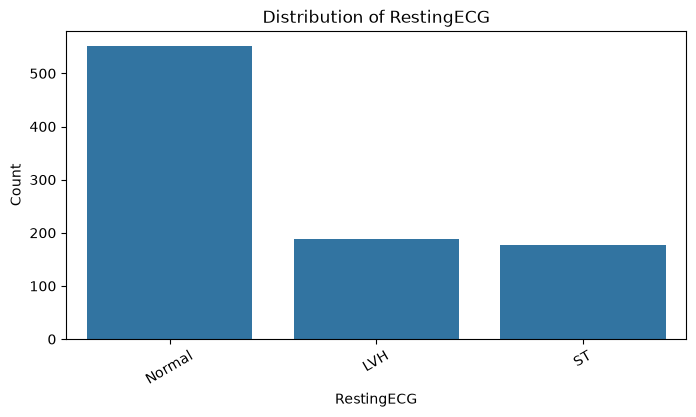

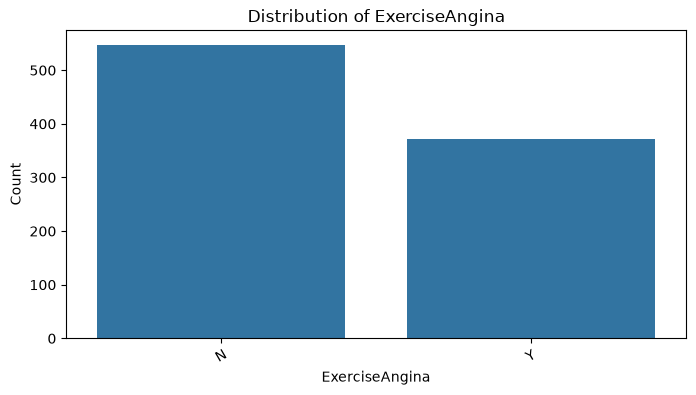

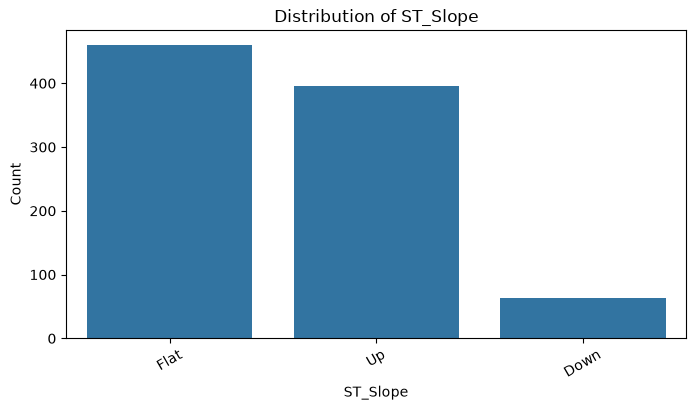

In [14]:
for column in categorical_features:
    plt.figure(figsize=(8, 4))

    sns.countplot(
        data=df,
        x=column,
        order=df[column].value_counts().index
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")

    plt.xticks(rotation=30)
    plt.savefig(f"C:/Users/pc/Desktop/inter/Cardiac_Patient_Monitoring/outputs/Distribution-of-{column}.png")
    plt.show()
    
 

### Charts: Categorical Feature Distributions

This loop creates a **count plot for every categorical feature**.

The five charts are:

1. **Distribution of Sex**
2. **Distribution of ChestPainType**
3. **Distribution of RestingECG**
4. **Distribution of ExerciseAngina**
5. **Distribution of ST_Slope**

For each chart:

- the x-axis lists the categories,
- the y-axis shows the number of patients,
- the categories are ordered from most frequent to least frequent.

### Chart 1 — Distribution of Sex

`M` is the dominant category with **725** observations, while `F` has 193. The dataset is therefore strongly male-dominated.

### Chart 2 — Distribution of ChestPainType

`ASY` is clearly the most frequent category with **496** observations. `NAP` and `ATA` are the next most common categories, while `TA` is much less frequent.

### Chart 3 — Distribution of RestingECG

`Normal` is the dominant category with **552** observations. `LVH` and `ST` are both substantially smaller groups.

### Chart 4 — Distribution of ExerciseAngina

`N` is more frequent than `Y`, with **547** observations in the `N` category. The chart therefore shows a noticeable but not extreme category imbalance.

### Chart 5 — Distribution of ST_Slope

`Flat` is the most frequent category with **460** observations. `Up` is the second-largest group, while `Down` is much less frequent.

### Why these charts matter

They reveal how much data is available for each category. Rare categories can provide less statistical evidence, while dominant categories can have a stronger influence on model learning. One-hot encoding later converts these categories into numerical columns.

## 5.4 Chart: Age Distribution by Heart Disease

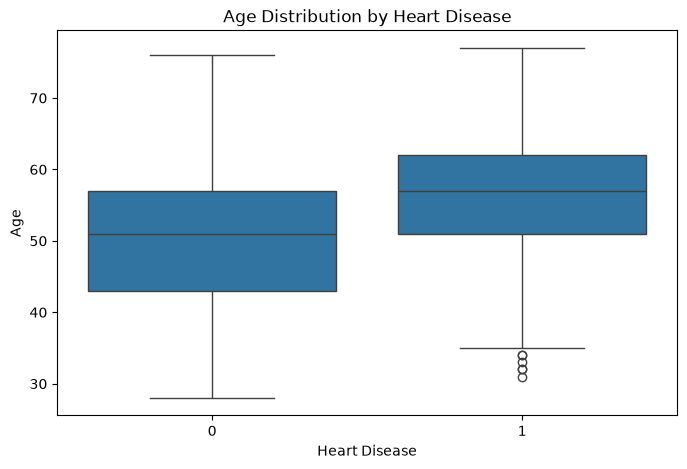

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Heart_Disease",
    y="Age"
)

plt.title("Age Distribution by Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Age")
plt.savefig(f"C:/Users/pc/Desktop/inter/Cardiac_Patient_Monitoring/outputs/Age-Distribution-by-Heart-Disease.png")
plt.show()

### Chart: Age Distribution by Heart Disease

This is a **boxplot** comparing Age for the two target classes.

- x-axis: Heart_Disease, where 0 means no disease and 1 means disease.
- y-axis: Age.
- The line inside each box is the median.
- The box covers the interquartile range, from the 25th to the 75th percentile.
- The whiskers show the non-outlier range.
- Individual points beyond the whiskers are potential outliers.

### What the chart shows

The median age for class 1 is visibly higher than the median age for class 0.

The class-0 median is around the low 50s, while the class-1 median is around the upper 50s.

The class-1 group also contains several lower-age observations shown as outliers.

### Interpretation

Age has a visible relationship with the target in this dataset: patients in the heart-disease class tend to be older.

This agrees with the numerical feature-target correlation, where Age has a positive correlation of about **0.245**.

## 5.5 Chart: Cholesterol by Heart Disease

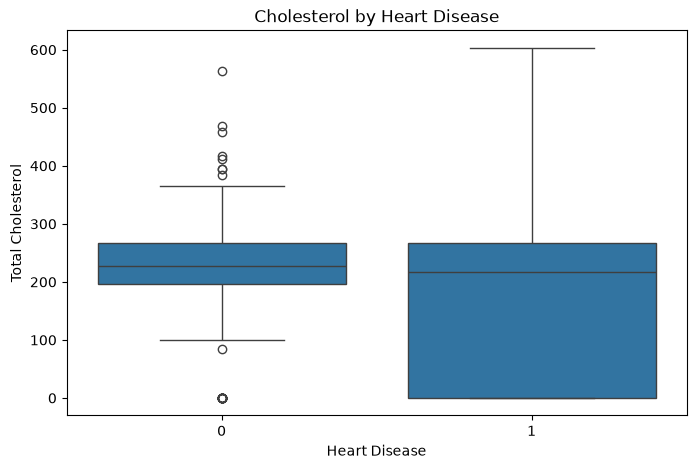

In [16]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Heart_Disease",
    y="Cholesterol"
)

plt.title("Cholesterol by Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Total Cholesterol")
plt.savefig(f"C:/Users/pc/Desktop/inter/Cardiac_Patient_Monitoring/outputs/Cholesterol-by-Heart-Disease.png")
plt.show()

### Chart: Cholesterol by Heart Disease

This is a **boxplot** comparing Cholesterol across the two target classes.

- x-axis: Heart_Disease.
- y-axis: Total Cholesterol.
- The box represents the middle 50% of values.
- The center line is the median.
- Points outside the whiskers are potential outliers.

### What the chart shows

The two groups have similar central cholesterol levels, with medians around the low-to-mid 200s.

However, the distributions are very wide and contain unusual values. In particular, class 0 has several high outliers, while class 1 spans a very broad range that includes values close to zero.

### Interpretation

Cholesterol alone does not provide a simple visual separation between the two classes. Its relationship with the target is actually negative in the numerical correlation analysis, about **-0.241**, but that correlation should not be interpreted as a causal medical relationship.

The unusual zero and extreme values are especially important when interpreting this synthetic dataset.

## 6.1 Calculate the Numerical Correlation Matrix

In [17]:
correlation_matrix = df[numeric_features].corr()

### What this code does

`df[numeric_features].corr()` calculates pairwise Pearson correlations among the six numerical predictor variables.

The result is stored in `correlation_matrix`.

### Why this matters

Correlation helps identify whether numerical variables move together and whether some variables may contain overlapping information.

The matrix is later visualized as a heatmap so the direction and strength of the relationships can be seen quickly.

## 6.2 Chart: Correlation Matrix Heatmap

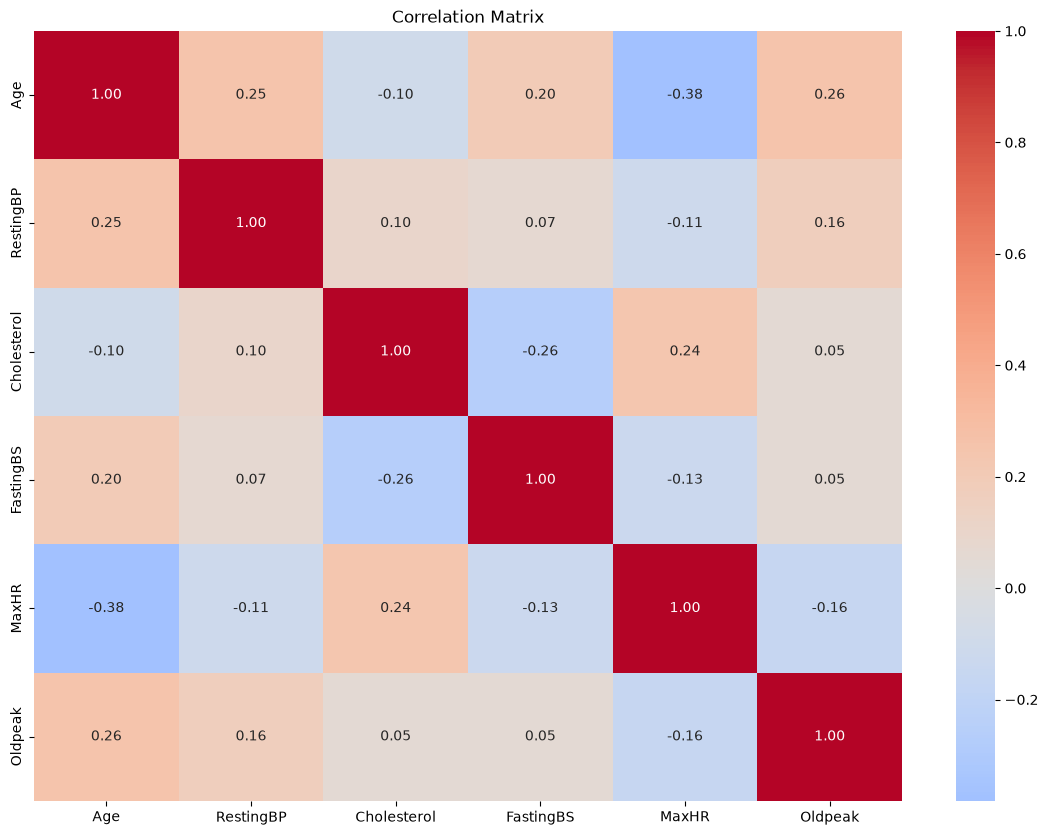

In [18]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.savefig(f"C:/Users/pc/Desktop/inter/Cardiac_Patient_Monitoring/outputs/Correlation-Matrix.png")
plt.show()

### Chart: Correlation Matrix

This is a **correlation heatmap** for the numerical variables.

- Each cell contains a correlation coefficient from -1 to +1.
- Values near +1 indicate a strong positive linear relationship.
- Values near -1 indicate a strong negative linear relationship.
- Values near 0 indicate a weak linear relationship.
- The diagonal is 1.00 because every variable is perfectly correlated with itself.

### Important relationships visible in the chart

- Age vs MaxHR = **-0.38**
- Cholesterol vs FastingBS = **-0.26**
- Age vs FastingBS = **0.20**
- Cholesterol vs MaxHR = **0.24**
- Age vs RestingBP = **0.25**
- MaxHR vs Oldpeak = **-0.16**

### Interpretation

The strongest relationship in this matrix is the negative association between Age and MaxHR.

Most other relationships are relatively weak, meaning the numerical variables are not simply duplicates of one another.

### Important limitation

Correlation measures linear association. It does not prove causation and does not capture every nonlinear relationship.

## 7.1 Define Features X and Target y

In [19]:
x = df.drop(columns=["Heart_Disease"])
y = df["Heart_Disease"]

print("X shape:", x.shape)
print("y shape:", y.shape)

X shape: (918, 11)
y shape: (918,)


### What this code does

The code separates the dataset into:

- `x`: all predictor variables except `Heart_Disease`.
- `y`: the target variable `Heart_Disease`.

### Result

- `X shape = (918, 11)`
- `y shape = (918,)`

This means the model receives **918 observations and 11 input features**, while the target contains one value for each observation.

### Why this matters

This is the standard supervised-learning structure:

**X → input features**

**y → value the model must predict**.

## 8.1 Create Training, Validation, and Test Sets

In [20]:
x_temp, x_test, y_temp, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

x_train, x_val, y_train, y_val = train_test_split(
    x_temp,
    y_temp,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("Training:", x_train.shape)
print("Validation:", x_val.shape)
print("Test:", x_test.shape)

Training: (587, 11)
Validation: (147, 11)
Test: (184, 11)


### What this code does

The dataset is split in two stages.

First:

- 80% goes into the development data (`x_temp`, `y_temp`).
- 20% is reserved as the final test set.

Second:

- 80% of the development data becomes training data.
- 20% of the development data becomes validation data.

The `stratify` argument keeps the class proportions approximately consistent across the splits.

### Result

- Training: **587 rows**
- Validation: **147 rows**
- Test: **184 rows**

Together these total 918 observations.

### Why this matters

The validation set is used to compare models and feature-engineering choices.

The final test set stays untouched until the end. This separation makes the final performance estimate more honest because the model-selection process did not directly optimize against the test set.

## 8.2 Build the Numerical Preprocessing Pipeline

In [21]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

### What this code does

This cell creates the preprocessing pipeline for numerical variables.

The numerical pipeline has two steps:

1. `SimpleImputer(strategy="median")` fills missing numerical values using the median.
2. `StandardScaler()` standardizes each numerical feature.

### Why median imputation?

The median is less affected by extreme values than the mean.

### Why scaling?

Standardization transforms a numerical feature so that its values are expressed relative to its mean and standard deviation. This is especially important for Logistic Regression because it helps put features on comparable scales.

## 8.3 Combine Numerical and Categorical Preprocessing

In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

### What this code does

`ColumnTransformer` combines two different preprocessing workflows.

For numerical columns it applies `numeric_transformer`.

For categorical columns it applies `categorical_transformer`, which:

1. fills missing categories with the most frequent category,
2. applies `OneHotEncoder`.

`handle_unknown="ignore"` means a previously unseen category will not crash the pipeline during validation or testing.

### Why this structure is important

The model receives one fully processed numerical matrix even though the original dataset contains mixed data types.

Putting preprocessing inside the pipeline also ensures that preprocessing is learned from the appropriate training fold during cross-validation rather than being fitted globally beforehand.

## 9.1 Build the Logistic Regression Pipeline

In [23]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE
            )
        )
    ]
)

### What this code does

This creates the first complete model pipeline.

The pipeline has:

1. `preprocessor`: cleans, scales, and encodes the input data.
2. `LogisticRegression`: performs the binary classification.

`max_iter=1000` gives Logistic Regression enough iterations to converge.

### Why Logistic Regression is the baseline

Logistic Regression is a strong and interpretable baseline for binary classification. It gives us a reference point against which the more flexible Random Forest can be compared.

## 9.2 Train Logistic Regression

In [24]:
logistic_pipeline.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Age','Sex','ChestPainType',...,'ExerciseAngina','Oldpeak','ST_Slope']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``,

### What this code does

`.fit(x_train, y_train)` trains the entire Logistic Regression pipeline.

Because the preprocessor is inside the pipeline, the numerical transformations and categorical encoding are fitted as part of the training process before the classifier learns the relationship between features and the target.

### Result

The returned object confirms that the pipeline contains:

- numerical imputation,
- numerical scaling,
- categorical imputation,
- one-hot encoding,
- Logistic Regression.

The model is now ready to predict validation cases.

## 9.3 Generate Logistic Regression Validation Predictions

In [25]:
y_val_pred_log = logistic_pipeline.predict(x_val)

y_val_prob_log = logistic_pipeline.predict_proba(x_val)[:, 1]

### What this code does

`predict(x_val)` produces the final class prediction for each validation patient.

`predict_proba(x_val)[:, 1]` returns the probability assigned to class 1, meaning the estimated probability of heart disease.

Two outputs are therefore created:

- `y_val_pred_log`: hard class predictions, 0 or 1.
- `y_val_prob_log`: probability estimates used by metrics such as ROC-AUC.

### Why both are needed

Confusion matrices and classification reports need class predictions.

ROC-AUC needs probability scores so it can evaluate model discrimination across different classification thresholds.

## 9.4 Evaluate Logistic Regression

In [26]:
log_val_res = evaluate_model(
    y_val,
    y_val_pred_log,
    y_val_prob_log)

log_val_res

{'Accuracy': 0.8027210884353742,
 'Precision': 0.8023255813953488,
 'Recall': 0.8518518518518519,
 'F1': 0.8263473053892215,
 'ROC-AUC': 0.9044145155256266}

### Logistic Regression Validation Results

The evaluation function returns:

| Metric | Score |
|---|---:|
| Accuracy | **0.803** |
| Precision | **0.802** |
| Recall | **0.852** |
| F1 | **0.826** |
| ROC-AUC | **0.904** |

### Interpretation

Accuracy of 0.803 means about 80.3% of validation patients were classified correctly.

Precision of 0.802 means that among patients predicted as having heart disease, about 80.2% were actually in class 1.

Recall of 0.852 means the model detected about 85.2% of the actual heart-disease cases.

F1 of 0.826 balances Precision and Recall.

ROC-AUC of 0.904 indicates strong ability to rank positive cases above negative cases.

### Main takeaway

The baseline is already useful, especially because its Recall is relatively high. However, there is room to improve, which motivates the Random Forest comparison.

## 9.5 Chart: Logistic Regression Validation Confusion Matrix

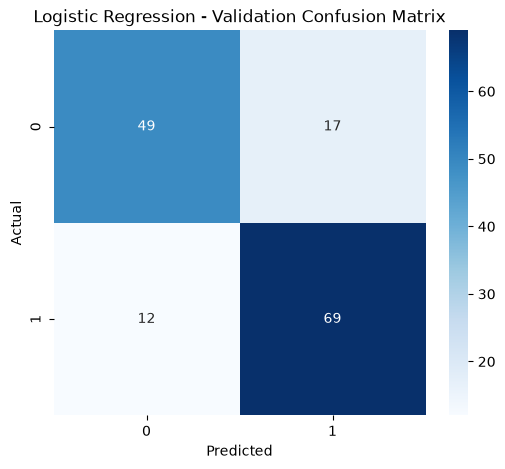

In [27]:
cm_logistic = confusion_matrix(
    y_val,
    y_val_pred_log
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression - Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig(f"C:/Users/pc/Desktop/inter/Cardiac_Patient_Monitoring/outputs/Logistic-Regression-Validation-Confusion-Matrix.png")
plt.show()

### Chart: Logistic Regression Validation Confusion Matrix

This heatmap has:

- rows = actual class,
- columns = predicted class,
- diagonal cells = correct predictions,
- off-diagonal cells = errors.

The four cells correspond to:

- True Negative: actual 0, predicted 0.
- False Positive: actual 0, predicted 1.
- False Negative: actual 1, predicted 0.
- True Positive: actual 1, predicted 1.

### How to read it

A strong classifier should have large values on the diagonal and relatively small values off the diagonal.

The chart provides a more concrete view of the Logistic Regression results than Accuracy alone because it shows exactly which type of mistake is being made.

## 9.6 Logistic Regression Classification Report

In [28]:
print(
    classification_report(
        y_val,
        y_val_pred_log,
        target_names=[
            "No Heart Disease",
            "Heart Disease"
        ]
    )
)

                  precision    recall  f1-score   support

No Heart Disease       0.80      0.74      0.77        66
   Heart Disease       0.80      0.85      0.83        81

        accuracy                           0.80       147
       macro avg       0.80      0.80      0.80       147
    weighted avg       0.80      0.80      0.80       147



### Logistic Regression Classification Report

The classification report gives class-level Precision, Recall, and F1-score.

For **No Heart Disease**:

- Precision = **0.80**
- Recall = **0.74**
- F1 = **0.77**
- Support = **66**

For **Heart Disease**:

- Precision = **0.80**
- Recall = **0.85**
- F1 = **0.83**
- Support = **81**

### Interpretation

The model performs better at recalling the heart-disease class than the no-disease class.

That is consistent with the overall Recall of about 0.852.

The difference matters because the project is a health-related classification exercise: failing to identify a positive case is represented by a false negative, so Recall deserves special attention.

## 10.1 Build the Random Forest Pipeline

In [29]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                class_weight="balanced"
            )
        )
    ]
)

### What this code does

This creates the second model pipeline using the same preprocessing as Logistic Regression.

The classifier is now `RandomForestClassifier` with:

- `n_estimators=200`: 200 decision trees.
- `class_weight="balanced"`: adjusts training emphasis according to class frequency.
- `n_jobs=-1`: uses available CPU cores.
- `random_state=42`: keeps the experiment reproducible.

### Why Random Forest is useful here

Random Forest can capture nonlinear relationships and interactions that a linear Logistic Regression model may not represent as effectively.

## 10.2 Train Random Forest

In [30]:
random_forest_pipeline.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Age','Sex','ChestPainType',...,'ExerciseAngina','Oldpeak','ST_Slope']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``,

### What this code does

`.fit(x_train, y_train)` trains the Random Forest pipeline using the same training data used for Logistic Regression.

The output confirms that the preprocessing and the 200-tree Random Forest classifier are connected inside one pipeline.

### Why the identical preprocessing matters

Using the same input preparation makes the comparison fair. The main difference between the original models is the classifier itself, not the data-cleaning process.

## 10.3 Generate Random Forest Validation Predictions

In [31]:
y_val_pred_rf = random_forest_pipeline.predict(x_val)

y_val_prob_rf = random_forest_pipeline.predict_proba(x_val)[:, 1]

### What this code does

This cell generates Random Forest predictions for the validation set.

- `y_val_pred_rf` contains class predictions.
- `y_val_prob_rf` contains the probability of class 1.

These outputs are used by the same evaluation function used for Logistic Regression, so the metrics are directly comparable.

## 10.4 Evaluate Random Forest

In [32]:
rf_val_res = evaluate_model(y_val,y_val_pred_rf,y_val_prob_rf)

rf_val_res

{'Accuracy': 0.8503401360544217,
 'Precision': 0.8314606741573034,
 'Recall': 0.9135802469135802,
 'F1': 0.8705882352941177,
 'ROC-AUC': 0.9098391320613542}

### Random Forest Validation Results

| Metric | Score |
|---|---:|
| Accuracy | **0.850** |
| Precision | **0.831** |
| Recall | **0.914** |
| F1 | **0.871** |
| ROC-AUC | **0.910** |

### Comparison with Logistic Regression

| Metric | Logistic | Random Forest | Change |
|---|---:|---:|---:|
| Accuracy | 0.803 | 0.850 | **+0.048** |
| Precision | 0.802 | 0.831 | **+0.029** |
| Recall | 0.852 | 0.914 | **+0.062** |
| F1 | 0.826 | 0.871 | **+0.044** |
| ROC-AUC | 0.904 | 0.910 | **+0.005** |

### Interpretation

Random Forest improves every validation metric.

The largest improvement is Recall: from about 85.2% to 91.4%.

That means Random Forest is better at identifying the actual heart-disease cases in this validation split.

The improvement in ROC-AUC is smaller than the improvement in the threshold-based metrics, but it still indicates slightly better overall ranking ability.

## 10.5 Compare the Two Original Validation Models

In [33]:
val_res = pd.DataFrame(
    [
        log_val_res,
        rf_val_res
    ],
    index=[
        "Logistic Regression",
        "Random Forest"
    ]
)

val_res

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.802721,0.802326,0.851852,0.826347,0.904415
Random Forest,0.850340,0.831461,0.913580,0.870588,0.909839


### Original Validation Model Comparison

This table puts the two original models side by side.

**Random Forest is the stronger validation model.**

It has higher:

- Accuracy: 0.850 vs 0.803
- Precision: 0.831 vs 0.802
- Recall: 0.914 vs 0.852
- F1: 0.871 vs 0.826
- ROC-AUC: 0.910 vs 0.904

### Why Random Forest wins this comparison

The Random Forest can represent nonlinear patterns and interactions between variables. That extra flexibility appears to help on this dataset.

At this point, however, validation performance alone is not enough. Cross-validation is used next to check whether the advantage is consistent across multiple splits.

## 11.1 Run Five-Fold Cross-Validation for Logistic Regression

In [34]:
cv = 5
log_cv = cross_validate(
    logistic_pipeline,
    x_temp,
    y_temp,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],
    n_jobs=-1
)

### What this code does

`cv = 5` requests five-fold cross-validation.

`cross_validate()` evaluates Logistic Regression using five different train/validation partitions of the development data.

The requested metrics are:

- Accuracy
- Precision
- Recall
- F1
- ROC-AUC

### Why use cross-validation?

A single validation split can be affected by which observations happen to fall into the validation set.

Five-fold cross-validation gives five performance measurements, allowing us to examine both the average score and its variability.

## 11.2 Summarize Logistic Regression Cross-Validation

In [35]:
log_cv_res = {
    "Accuracy Mean": log_cv["test_accuracy"].mean(),
    "Accuracy Std": log_cv["test_accuracy"].std(),

    "Precision Mean": log_cv["test_precision"].mean(),
    "Precision Std": log_cv["test_precision"].std(),

    "Recall Mean": log_cv["test_recall"].mean(),
    "Recall Std": log_cv["test_recall"].std(),

    "F1 Mean": log_cv["test_f1"].mean(),
    "F1 Std": log_cv["test_f1"].std(),

    "ROC-AUC Mean": log_cv["test_roc_auc"].mean(),
    "ROC-AUC Std": log_cv["test_roc_auc"].std()
}

log_cv_res

{'Accuracy Mean': np.float64(0.8487093467523996),
 'Accuracy Std': np.float64(0.03004507589096429),
 'Precision Mean': np.float64(0.8564207585824786),
 'Precision Std': np.float64(0.034231565996177854),
 'Recall Mean': np.float64(0.8742547425474255),
 'Recall Std': np.float64(0.027836107378482636),
 'F1 Mean': np.float64(0.8648610719764566),
 'F1 Std': np.float64(0.02555025929121738),
 'ROC-AUC Mean': np.float64(0.9213880588948339),
 'ROC-AUC Std': np.float64(0.03300423881159855)}

### Logistic Regression Cross-Validation Results

The dictionary calculates the mean and standard deviation for every metric.

| Metric | Mean | Std |
|---|---:|---:|
| Accuracy | **0.849** | 0.030 |
| Precision | **0.856** | 0.034 |
| Recall | **0.874** | 0.028 |
| F1 | **0.865** | 0.026 |
| ROC-AUC | **0.921** | 0.033 |

### Interpretation

The mean is the average performance across the five folds.

The standard deviation measures how much the score changes from fold to fold.

For example, Accuracy has a mean of 0.849 with a standard deviation of 0.030, so the model's accuracy is reasonably stable but not identical across folds.

## 11.3 Run Five-Fold Cross-Validation for Random Forest

In [36]:
rf_cv = cross_validate(
    random_forest_pipeline,
    x_temp,
    y_temp,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],
    n_jobs=-1
)

### What this code does

This repeats the same five-fold cross-validation procedure for Random Forest.

The same metrics and the same development data are used.

### Why this is a fair comparison

Both models are evaluated under the same cross-validation design. Therefore, differences in the resulting scores are meaningful model differences rather than differences in the evaluation procedure.

## 11.4 Summarize Random Forest Cross-Validation

In [37]:
rf_cv_res = {
    "Accuracy Mean": rf_cv["test_accuracy"].mean(),
    "Accuracy Std": rf_cv["test_accuracy"].std(),

    "Precision Mean": rf_cv["test_precision"].mean(),
    "Precision Std": rf_cv["test_precision"].std(),

    "Recall Mean": rf_cv["test_recall"].mean(),
    "Recall Std": rf_cv["test_recall"].std(),

    "F1 Mean": rf_cv["test_f1"].mean(),
    "F1 Std": rf_cv["test_f1"].std(),

    "ROC-AUC Mean": rf_cv["test_roc_auc"].mean(),
    "ROC-AUC Std": rf_cv["test_roc_auc"].std()
}

rf_cv_res

{'Accuracy Mean': np.float64(0.8555586618208928),
 'Accuracy Std': np.float64(0.017140202123921183),
 'Precision Mean': np.float64(0.8711475741011606),
 'Precision Std': np.float64(0.03128279902183627),
 'Recall Mean': np.float64(0.8694068051791628),
 'Recall Std': np.float64(0.02791371764505887),
 'F1 Mean': np.float64(0.869486854244027),
 'F1 Std': np.float64(0.014373895546250874),
 'ROC-AUC Mean': np.float64(0.9254718472333648),
 'ROC-AUC Std': np.float64(0.024979719441242297)}

### Random Forest Cross-Validation Results

| Metric | Mean | Std |
|---|---:|---:|
| Accuracy | **0.856** | 0.017 |
| Precision | **0.871** | 0.031 |
| Recall | **0.869** | 0.028 |
| F1 | **0.869** | 0.014 |
| ROC-AUC | **0.925** | 0.025 |

### Interpretation

Random Forest has the higher mean Accuracy, Precision, F1, and ROC-AUC.

Its Accuracy standard deviation is also lower than Logistic Regression's:

- Logistic Regression: 0.030
- Random Forest: 0.017

Its F1 standard deviation is much lower as well:

- Logistic Regression: 0.026
- Random Forest: 0.014

That suggests Random Forest is not only slightly stronger on average but also more stable for these metrics across folds.

Logistic Regression has a slightly higher mean Recall: 0.874 vs 0.869. This is the one cross-validation metric where Logistic Regression is ahead.

## 11.5 Compare Cross-Validation Results

In [38]:
cv_compare = pd.DataFrame(
    [
        log_cv_res,
        rf_cv_res
    ],
    index=[
        "Logistic Regression",
        "Random Forest"
    ]
)

cv_compare

,Accuracy Mean,Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1 Mean,F1 Std,ROC-AUC Mean,ROC-AUC Std
Logistic Regression,0.848709,0.030045,0.856421,0.034232,0.874255,0.027836,0.864861,0.025550,0.921388,0.033004
Random Forest,0.855559,0.017140,0.871148,0.031283,0.869407,0.027914,0.869487,0.014374,0.925472,0.024980


### Cross-Validation Comparison

| Metric | Logistic Regression | Random Forest | Better |
|---|---:|---:|---|
| Accuracy Mean | 0.849 | **0.856** | Random Forest |
| Precision Mean | 0.856 | **0.871** | Random Forest |
| Recall Mean | **0.874** | 0.869 | Logistic Regression |
| F1 Mean | 0.865 | **0.869** | Random Forest |
| ROC-AUC Mean | 0.921 | **0.925** | Random Forest |

### Stability comparison

Random Forest also has lower variability for Accuracy, F1, and ROC-AUC.

### Decision

The overall cross-validation evidence favors **Random Forest**.

The important nuance is that Logistic Regression has slightly higher average Recall. Therefore, the model choice is not based on one metric; it is based on the overall balance of Accuracy, Precision, F1, ROC-AUC, and stability.

## 12.1 Calculate Numerical Feature–Target Correlations

In [39]:
feature_target_corr = (
    df.loc[x_temp.index]
    .select_dtypes(include=["int64", "float64"])
    .corr()["Heart_Disease"]
    .drop("Heart_Disease")
    .sort_values(key=abs, ascending=False)
)

feature_target_corr

MaxHR         -0.407227
Oldpeak        0.376603
FastingBS      0.261391
Age            0.244689
Cholesterol   -0.241413
RestingBP      0.102055
Name: Heart_Disease, dtype: float64

### What this code does

This calculates Pearson correlation between each numerical predictor and `Heart_Disease`, using the development portion only.

The correlations are sorted by absolute magnitude, so the strongest positive and negative relationships appear first.

### Results

| Feature | Correlation with Heart Disease |
|---|---:|
| MaxHR | **-0.407** |
| Oldpeak | **+0.377** |
| FastingBS | **+0.261** |
| Age | **+0.245** |
| Cholesterol | **-0.241** |
| RestingBP | **+0.102** |

### Interpretation

The strongest numerical relationship is MaxHR, with a negative correlation.

Oldpeak has the strongest positive correlation among these numerical features.

These correlations are useful for identifying potentially informative variables, but they are not causal conclusions and they do not measure nonlinear relationships.

## 12.2 Chart: Feature Correlation with Heart Disease

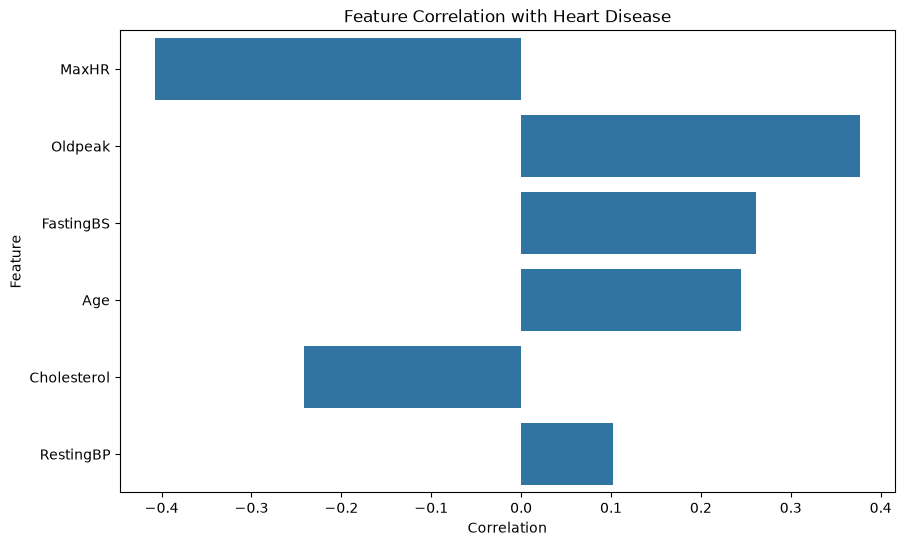

In [40]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=feature_target_corr.values,
    y=feature_target_corr.index
)

plt.title("Feature Correlation with Heart Disease")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.savefig(f"C:/Users/pc/Desktop/inter/Cardiac_Patient_Monitoring/outputs/Feature-Correlation-with-Heart-Disease.png")

plt.show()

### Chart: Feature Correlation with Heart Disease

This horizontal bar chart visualizes the six correlations from the previous cell.

- The x-axis is correlation.
- The y-axis lists numerical features.
- Bars extending left represent negative correlations.
- Bars extending right represent positive correlations.
- Longer bars indicate stronger absolute linear association.

### Chart interpretation

**MaxHR** has the longest negative bar at about **-0.407**.

**Oldpeak** has the longest positive bar at about **+0.377**.

**FastingBS** and **Age** have moderate positive bars.

**Cholesterol** has a moderate negative bar.

**RestingBP** is close to zero compared with the other features, so its linear association with the target is relatively weak.

### Why this chart matters

It gives a fast visual ranking of numerical variables by their linear association with the target. It does not replace model-based feature importance because correlation cannot capture categorical effects or nonlinear interactions.

## 12.3 Extract Random Forest Feature Importances

In [41]:
rf_prep = random_forest_pipeline.named_steps["preprocessor"]

rf_model = random_forest_pipeline.named_steps["classifier"]

feature_names = rf_prep.get_feature_names_out()

feature_importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
19,cat__ST_Slope_Up,0.151754
2,num__Cholesterol,0.102484
4,num__MaxHR,0.091925
18,cat__ST_Slope_Flat,0.091308
5,num__Oldpeak,0.088896
8,cat__ChestPainType_ASY,0.083292
0,num__Age,0.070443
1,num__RestingBP,0.061369
16,cat__ExerciseAngina_Y,0.060804
15,cat__ExerciseAngina_N,0.059956


### What this code does

This extracts feature importance values from the already trained original Random Forest.

Because categorical variables were one-hot encoded, the importance values are attached to transformed feature names such as:

`cat__ST_Slope_Up`

or

`num__MaxHR`.

The resulting table is sorted from most important to least important and the top 15 are displayed.

### Top results

The most important original transformed features are:

1. `cat__ST_Slope_Up` — **0.1518**
2. `num__Cholesterol` — **0.1025**
3. `num__MaxHR` — **0.0919**
4. `cat__ST_Slope_Flat` — **0.0913**
5. `num__Oldpeak` — **0.0889**
6. `cat__ChestPainType_ASY` — **0.0833**
7. `num__Age` — **0.0704**

### Important distinction

Random Forest feature importance measures how much the transformed feature contributes to the tree ensemble's predictive decisions. It is not the same thing as correlation and should not be interpreted as causation.

## 12.4 Chart: Top 15 Random Forest Feature Importances

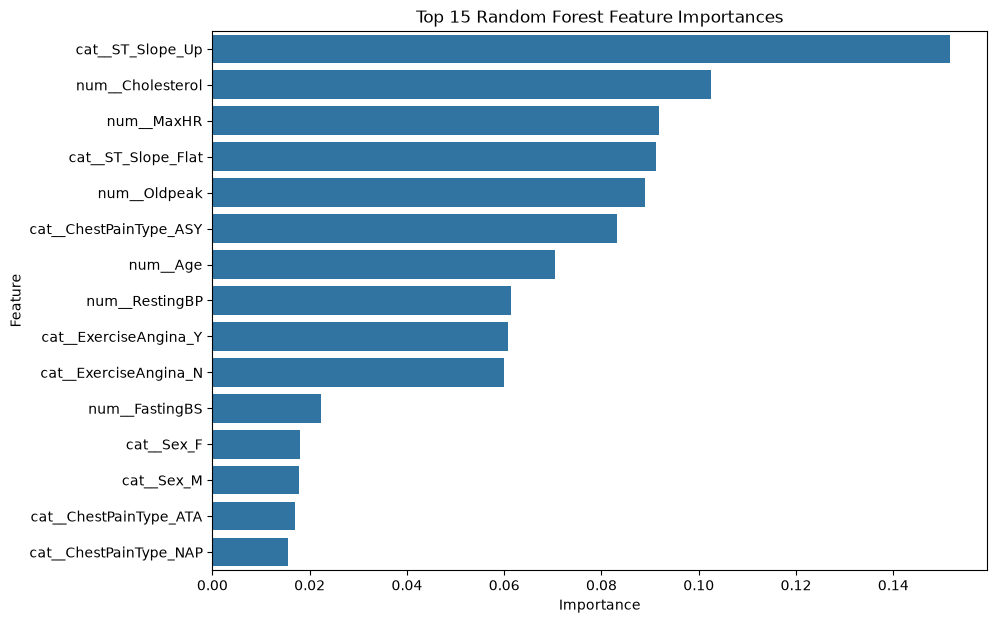

In [42]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.savefig(f"C:/Users/pc/Desktop/inter/Cardiac_Patient_Monitoring/outputs/Top-15-Random-Forest-Feature-Importances.png")

plt.show()

### Chart: Top 15 Random Forest Feature Importances

This horizontal bar chart ranks the 15 most important transformed features used by the original Random Forest.

### What the chart shows

The longest bar is:

**`cat__ST_Slope_Up` ≈ 0.152**

followed by:

- `num__Cholesterol` ≈ 0.102
- `num__MaxHR` ≈ 0.092
- `cat__ST_Slope_Flat` ≈ 0.091
- `num__Oldpeak` ≈ 0.089
- `cat__ChestPainType_ASY` ≈ 0.083
- `num__Age` ≈ 0.070

### Interpretation

The Random Forest relies heavily on ST-slope categories, followed by numerical variables such as Cholesterol, MaxHR, Oldpeak, and Age.

This differs from the correlation chart because feature importance captures the model's use of variables within tree splits, including nonlinear patterns and interactions.

### Why this matters

The chart helps identify which transformed inputs are most influential for the Random Forest's predictions, while the correlation chart answers a different question about linear association with the target.

## 12.5 Select the Top Numerical Features for Feature Engineering

In [43]:
top_numeric_features = feature_target_corr.head(5).index.tolist()

top_numeric_features

['MaxHR', 'Oldpeak', 'FastingBS', 'Age', 'Cholesterol']

### What this code does

The five strongest numerical correlations are selected with:

`feature_target_corr.head(5).index.tolist()`.

### Result

The selected features are:

1. MaxHR
2. Oldpeak
3. FastingBS
4. Age
5. Cholesterol

### Why this matters

These features are used as the basis for the next feature-engineering stage.

The notebook does not directly replace the original variables. Instead, the imported feature-engineering function creates additional features intended to represent relationships between existing measurements.

## 13.1 Create Engineered Features for Development, Validation, and Test Data

In [44]:
x_temp_engineered = add_engineered_features(x_temp)

x_val_engineered = add_engineered_features(x_val)

x_test_engineered = add_engineered_features(x_test)

### What this code does

`add_engineered_features()` is applied separately to the temporary development data, validation data, and test data.

The new datasets are stored as:

- `x_temp_engineered`
- `x_val_engineered`
- `x_test_engineered`

### Why this matters

The same feature-engineering transformation must be applied consistently to every split.

### Important source limitation

The exact implementation of `add_engineered_features()` is not contained inside this notebook; it is imported from `src.engineered_features`.

Therefore, this notebook can document the engineered feature names produced by the function, but it should not invent exact mathematical formulas that are not present in the uploaded notebook.

The later output shows the engineered variables that were actually created.

## 13.2 Identify Engineered Numerical and Categorical Features

In [45]:
x_train_engineered = add_engineered_features(x_train)

numeric_features_engineered = x_train_engineered.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features_engineered = x_train_engineered.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical:", numeric_features_engineered)
print("Categorical:", categorical_features_engineered)

Numerical: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'Cholesterol_Age_Ratio', 'MaxHR_Age_Ratio', 'BP_Age_Ratio', 'Heart_Stress']
Categorical: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


C:\Users\pc\AppData\Local\Temp\ipykernel_24832\2869065395.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features_engineered = x_train_engineered.select_dtypes(


### What this code does

The training data is transformed with `add_engineered_features()`.

Then the cell automatically detects which columns are numerical and which are categorical after feature engineering.

### Result

The engineered numerical variables are:

- Age
- RestingBP
- Cholesterol
- FastingBS
- MaxHR
- Oldpeak
- Cholesterol_Age_Ratio
- MaxHR_Age_Ratio
- BP_Age_Ratio
- Heart_Stress

The categorical variables remain:

- Sex
- ChestPainType
- RestingECG
- ExerciseAngina
- ST_Slope

### Interpretation

Feature engineering increased the numerical representation from 6 original numerical variables to 10 numerical variables.

The ratio features are intended to combine existing measurements into relative relationships. `Heart_Stress` is another engineered numerical variable, but its exact formula is defined in the external `src.engineered_features` module rather than this notebook.

## 13.3 Build the Engineered Numerical and Categorical Transformers

In [46]:
numeric_transformer_engineered = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer_engineered = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

### What this code does

This recreates the numerical and categorical preprocessing pipelines for the engineered dataset.

The numerical variables are:

1. median imputed,
2. standardized.

The categorical variables are:

1. most-frequent imputed,
2. one-hot encoded.

### Why rebuild the transformer?

The engineered dataset has additional numerical columns, so the numerical column list has changed. A new preprocessing object is therefore required to match the new feature space.

## 13.4 Combine the Engineered Preprocessing Steps

In [47]:
preprocessor_engineered = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer_engineered,
            numeric_features_engineered
        ),
        (
            "cat",
            categorical_transformer_engineered,
            categorical_features_engineered
        )
    ]
)

### What this code does

This `ColumnTransformer` combines the engineered numerical and categorical preprocessing.

The result is the preprocessing stage that both engineered Logistic Regression and engineered Random Forest will use.

### Why this matters

It guarantees that the engineered features receive the same consistent transformations before entering the models.

## 13.5 Build the Engineered Logistic Regression Pipeline

In [48]:
final_log_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_engineered
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE
            )
        )
    ]
)

### What this code does

This builds the Logistic Regression pipeline for the engineered dataset.

The structure remains:

**engineered features → preprocessing → Logistic Regression**

The classifier configuration is the same as the original Logistic Regression model.

### Why keep the classifier settings the same?

This makes the before-versus-after feature-engineering comparison cleaner. The main experimental change is the input feature representation.

## 13.6 Build the Engineered Random Forest Pipeline

In [49]:
final_rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_engineered
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                class_weight="balanced"
            )
        )
    ]
)

### What this code does

This builds the Random Forest pipeline for the engineered dataset.

It keeps the same Random Forest settings:

- 200 trees,
- balanced class weights,
- all available CPU cores,
- fixed random state.

### Why this comparison is useful

The model architecture is held constant while the feature representation changes. This lets us ask a clear question:

**Did the engineered features improve the same model?**

## 13.7 Train the Engineered Logistic Regression Model

In [50]:
final_log_pipeline.fit(x_train_engineered,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Age','Sex','ChestPainType',...,'MaxHR_Age_Ratio','BP_Age_Ratio', 'Heart_Stress']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pass

### What this code does

This trains the engineered Logistic Regression pipeline using the original training split.

The model learns from the additional engineered variables as well as the original variables.

### Why this is a separate model

The original Logistic Regression remains available as the baseline. This new model allows a direct before-and-after comparison.

## 13.8 Train the Engineered Random Forest Model

In [51]:
final_rf_pipeline.fit(x_train_engineered,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Age','Sex','ChestPainType',...,'MaxHR_Age_Ratio','BP_Age_Ratio', 'Heart_Stress']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pass

### What this code does

This trains the engineered Random Forest using the original training split.

The classifier is unchanged from the original Random Forest; only the feature representation has been expanded.

### Why this matters

This is the cleanest test of whether the engineered variables add useful predictive information to the Random Forest.

## 13.9 Generate Engineered Logistic Regression Validation Predictions

In [52]:
log_engineered_pred = final_log_pipeline.predict(x_val_engineered)

log_engineered_prob = final_log_pipeline.predict_proba(x_val_engineered)[:, 1]

### What this code does

The engineered Logistic Regression predicts the validation set.

Two outputs are created:

- class predictions in `log_engineered_pred`,
- class-1 probabilities in `log_engineered_prob`.

These are then evaluated using the same metrics as the original model.

## 13.10 Generate Engineered Random Forest Validation Predictions

In [53]:
rf_engineered_pred = final_rf_pipeline.predict(x_val_engineered)

rf_engineered_prob = final_rf_pipeline.predict_proba(x_val_engineered)[:, 1]

### What this code does

The engineered Random Forest predicts the validation set.

Again, both class predictions and class-1 probabilities are generated so that all five evaluation metrics can be calculated consistently.

## 13.11 Evaluate the Engineered Models

In [54]:
log_engineered_res = evaluate_model(
    y_val,
    log_engineered_pred,
    log_engineered_prob
)

rf_engineered_res = evaluate_model(
    y_val,
    rf_engineered_pred,
    rf_engineered_prob
)

### What this code does

This evaluates both engineered models using exactly the same validation labels and the same evaluation function used earlier.

The two result dictionaries are:

- `log_engineered_res`
- `rf_engineered_res`

These become the basis for the original-versus-engineered comparison.

## 13.12 Compare Original and Engineered Models

In [55]:
engineered_comparison = pd.DataFrame(
    [
        log_val_res,
        log_engineered_res,
        rf_val_res,
        rf_engineered_res
    ],
    index=[
        "Logistic Regression - Original",
        "Logistic Regression - Engineered",
        "Random Forest - Original",
        "Random Forest - Engineered"
    ]
)

engineered_comparison

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression - Original,0.802721,0.802326,0.851852,0.826347,0.904415
Logistic Regression - Engineered,0.802721,0.809524,0.839506,0.824242,0.901796
Random Forest - Original,0.850340,0.831461,0.913580,0.870588,0.909839
Random Forest - Engineered,0.843537,0.829545,0.901235,0.863905,0.908997


### Original vs Engineered Validation Comparison

This is one of the most important comparison tables in the notebook because it shows whether feature engineering actually helped.

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Logistic — Original | 0.803 | 0.802 | 0.852 | 0.826 | 0.904 |
| Logistic — Engineered | 0.803 | **0.810** | 0.840 | 0.824 | 0.902 |
| Random Forest — Original | **0.850** | **0.831** | **0.914** | **0.871** | **0.910** |
| Random Forest — Engineered | 0.844 | 0.830 | 0.901 | 0.864 | 0.909 |

### Logistic Regression: what changed?

Accuracy stayed exactly the same at 0.803.

Precision improved from 0.802 to 0.810.

However, Recall decreased from 0.852 to 0.840.

F1 decreased slightly from 0.826 to 0.824.

ROC-AUC decreased from 0.904 to 0.902.

### Why did the Logistic Regression result get slightly worse?

The engineered variables added extra information, but that information did not translate into better overall separation on this validation split. The model gained a small Precision improvement while losing Recall, so the balance measured by F1 and ROC-AUC became slightly worse.

### Random Forest: what changed?

Accuracy decreased from 0.850 to 0.844.

Precision decreased slightly from 0.831 to 0.830.

Recall decreased from 0.914 to 0.901.

F1 decreased from 0.871 to 0.864.

ROC-AUC decreased slightly from 0.910 to 0.909.

### Why did Random Forest get worse?

The engineered features increased the feature space, but the new variables did not add enough useful information to improve validation performance. Instead, they appear to have introduced additional representations that did not generalize as well on this validation split.

### Decision

Feature engineering **did not improve either model on the validation set**.

Therefore, the notebook keeps the original Random Forest feature representation for model selection rather than assuming that more features automatically means a better model.

## 13.13 Print the Complete Validation and Cross-Validation Comparison

In [56]:
print("Validation Results")
print(engineered_comparison)

print("\nCross-Validation Results")
print(cv_compare)

Validation Results
                                  Accuracy  Precision    Recall        F1  \
Logistic Regression - Original    0.802721   0.802326  0.851852  0.826347   
Logistic Regression - Engineered  0.802721   0.809524  0.839506  0.824242   
Random Forest - Original          0.850340   0.831461  0.913580  0.870588   
Random Forest - Engineered        0.843537   0.829545  0.901235  0.863905   

                                   ROC-AUC  
Logistic Regression - Original    0.904415  
Logistic Regression - Engineered  0.901796  
Random Forest - Original          0.909839  
Random Forest - Engineered        0.908997  

Cross-Validation Results
                     Accuracy Mean  Accuracy Std  Precision Mean  \
Logistic Regression       0.848709      0.030045        0.856421   
Random Forest             0.855559      0.017140        0.871148   

                     Precision Std  Recall Mean  Recall Std   F1 Mean  \
Logistic Regression       0.034232     0.874255    0.027836  0.864

### Complete Validation and Cross-Validation Results

This cell prints both major evaluation stages together.

### Validation comparison

The **original Random Forest** is the strongest model in the direct validation comparison:

- Accuracy = **0.850**
- Precision = **0.831**
- Recall = **0.914**
- F1 = **0.871**
- ROC-AUC = **0.910**

### Cross-validation comparison

Random Forest also has the strongest overall cross-validation profile:

- Accuracy Mean = **0.856**
- Precision Mean = **0.871**
- F1 Mean = **0.869**
- ROC-AUC Mean = **0.925**

Logistic Regression has slightly higher cross-validation Recall:

- Logistic Regression = **0.874**
- Random Forest = **0.869**

### Important methodological observation

The comparison in this notebook actually shows that **feature engineering did not improve the validation results**. The original Random Forest is better than the engineered Random Forest on all five validation metrics.

However, the next cell retrains `final_rf_pipeline`, and `final_rf_pipeline` is the **engineered Random Forest pipeline**.

Therefore, there is a methodological inconsistency:

- The validation comparison favors the **original Random Forest**.
- The code used for the final test evaluation is the **engineered Random Forest**.

So the statement that the final model was selected strictly because it was the best validation model is not fully supported by the actual code. The final test results are valid for the model that was actually trained, but the notebook should clearly distinguish that model from the validation winner.

### Why this distinction matters

It prevents us from incorrectly claiming that feature engineering improved the model. The validation evidence says the opposite, while the final code chooses to evaluate the engineered Random Forest anyway.

## 14.1 Retrain the Selected Random Forest on All Development Data

In [57]:
X_development_engineered = add_engineered_features(
    x_temp
)

final_rf_pipeline.fit(
    X_development_engineered,
    y_temp
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Age','Sex','ChestPainType',...,'MaxHR_Age_Ratio','BP_Age_Ratio', 'Heart_Stress']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pass

### What this code does

The code creates engineered features for **all development data** and then fits `final_rf_pipeline` on that complete development set.

This means:

1. The training and validation observations are combined through `x_temp`.
2. Engineered features are created for that development data.
3. The engineered Random Forest pipeline is retrained using all development labels.
4. The test set remains untouched.

### Why retraining on all development data is normally useful

After model selection, it is common to use all available development observations to train the chosen model before evaluating it once on the test set.

### Important methodological issue in this notebook

`final_rf_pipeline` is the **engineered Random Forest pipeline**.

But the earlier validation comparison showed:

- Original Random Forest: **Accuracy 0.850, F1 0.871, ROC-AUC 0.910**
- Engineered Random Forest: **Accuracy 0.844, F1 0.864, ROC-AUC 0.909**

So the code is not retraining the validation winner. It is retraining the engineered version instead.

This should be reported honestly: **the final test result evaluates the engineered Random Forest, even though the validation comparison favored the original Random Forest.**

## 14.2 Generate Final Test Predictions

In [58]:
final_test_pred = final_rf_pipeline.predict(
    x_test_engineered
)

final_test_prob = final_rf_pipeline.predict_proba(
    x_test_engineered
)[:, 1]

### What this code does

The final trained Random Forest predicts the previously untouched test set.

Two outputs are produced:

- `final_test_pred`: predicted class for each test patient.
- `final_test_prob`: predicted probability of heart disease.

### Why this is the critical evaluation step

The test set was not used for model selection, feature-engineering decisions, or cross-validation. Therefore, this is the notebook's final unbiased performance estimate within this experimental setup.

## 14.3 Calculate Final Test Metrics

In [59]:
final_res = evaluate_model(
    y_test,
    final_test_pred,
    final_test_prob
)

final_res

{'Accuracy': 0.9021739130434783,
 'Precision': 0.8962264150943396,
 'Recall': 0.9313725490196079,
 'F1': 0.9134615384615384,
 'ROC-AUC': 0.9424318507890961}

### Final Test Results

| Metric | Final Test Score |
|---|---:|
| Accuracy | **0.902** |
| Precision | **0.896** |
| Recall | **0.931** |
| F1 | **0.913** |
| ROC-AUC | **0.942** |

### Interpretation

The final model correctly classifies about **90.2%** of the 184 test patients.

Recall is **93.1%**, meaning the model identifies most of the actual heart-disease cases.

Precision is **89.6%**, meaning most patients predicted as positive are actually positive in this test set.

F1 is **91.3%**, showing a strong balance between Precision and Recall.

ROC-AUC is **0.942**, indicating strong discrimination between the two classes.

### Important comparison with validation

The final test scores are higher than the earlier validation scores for the selected Random Forest.

For example:

- Validation Accuracy: 0.850 → Test Accuracy: 0.902
- Validation Recall: 0.914 → Test Recall: 0.931
- Validation F1: 0.871 → Test F1: 0.913
- Validation ROC-AUC: 0.910 → Test ROC-AUC: 0.942

This does **not** mean the model suddenly learned from the test set. The model was retrained on more development data before testing, and the test split itself may simply be easier than the validation split. A single test set can naturally produce a higher or lower score.

### Bottom line

The final model performs strongly on the held-out test set, but because the dataset is synthetic, these scores should not be interpreted as clinical performance.

## 14.4 Final Test Classification Report

In [60]:
print(
    classification_report(
        y_test,
        final_test_pred,
        target_names=[
            "No Heart Disease",
            "Heart Disease"
        ]
    )
)

                  precision    recall  f1-score   support

No Heart Disease       0.91      0.87      0.89        82
   Heart Disease       0.90      0.93      0.91       102

        accuracy                           0.90       184
       macro avg       0.90      0.90      0.90       184
    weighted avg       0.90      0.90      0.90       184



### Final Test Classification Report

For **No Heart Disease**:

- Precision = **0.91**
- Recall = **0.87**
- F1 = **0.89**
- Support = **82**

For **Heart Disease**:

- Precision = **0.90**
- Recall = **0.93**
- F1 = **0.91**
- Support = **102**

### Interpretation

The final model has particularly strong Recall for the heart-disease class: **0.93**.

That means only a small portion of actual positive cases were missed.

The performance is also reasonably balanced across the two classes, with both class-level F1-scores close to 0.90 or above.

## 14.5 Chart: Final Model Test Confusion Matrix

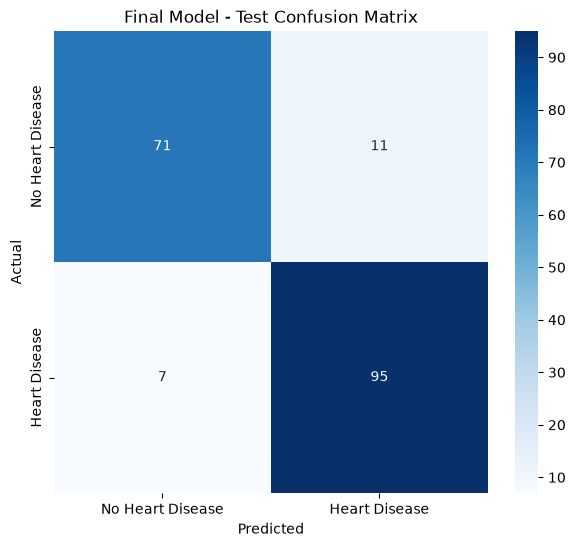

In [61]:
final_cm = confusion_matrix(
    y_test,
    final_test_pred
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "No Heart Disease",
        "Heart Disease"
    ],
    yticklabels=[
        "No Heart Disease",
        "Heart Disease"
    ]
)

plt.title("Final Model - Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig(f"C:/Users/pc/Desktop/inter/Cardiac_Patient_Monitoring/outputs/Final-Model-Test-Confusion-Matrix.png")

plt.show()

### Chart: Final Model Test Confusion Matrix

This is the final model's confusion matrix on the untouched test set.

The axes are explicitly labeled:

- y-axis = Actual class
- x-axis = Predicted class

The four cells are:

| | Predicted No Disease | Predicted Heart Disease |
|---|---:|---:|
| Actual No Disease | **71** | **11** |
| Actual Heart Disease | **7** | **95** |

### Exact interpretation

**True Negative = 71**

The model correctly predicted no heart disease for 71 patients who actually had no heart disease.

**False Positive = 11**

The model predicted heart disease for 11 patients who actually did not have heart disease.

**False Negative = 7**

The model predicted no heart disease for 7 patients who actually had heart disease.

**True Positive = 95**

The model correctly predicted heart disease for 95 patients who actually had heart disease.

### Why this chart is important

It shows that the model has more true positives than false negatives, which explains the high Recall of about 93.1%.

It also makes the two types of errors visible rather than hiding them inside one Accuracy number.

## 14.6 Read the Final Confusion Matrix Values

In [62]:
tn, fp, fn, tp = final_cm.ravel()

print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)

True Negative : 71
False Positive: 11
False Negative: 7
True Positive : 95


### What this code does

`final_cm.ravel()` extracts the four cells of the confusion matrix in the standard binary order:

`tn, fp, fn, tp`

The notebook then prints them individually.

### Result

- True Negative = **71**
- False Positive = **11**
- False Negative = **7**
- True Positive = **95**

### Relationship to the metrics

These four values are the raw counts behind the final classification metrics.

For example:

- Recall = TP / (TP + FN) = 95 / (95 + 7) ≈ **0.931**
- Precision = TP / (TP + FP) = 95 / (95 + 11) ≈ **0.896**
- Accuracy = (TP + TN) / total = (95 + 71) / 184 ≈ **0.902**

This is a useful verification that the reported metrics are consistent with the confusion matrix.

## 14.7 Chart: Final Model ROC Curve

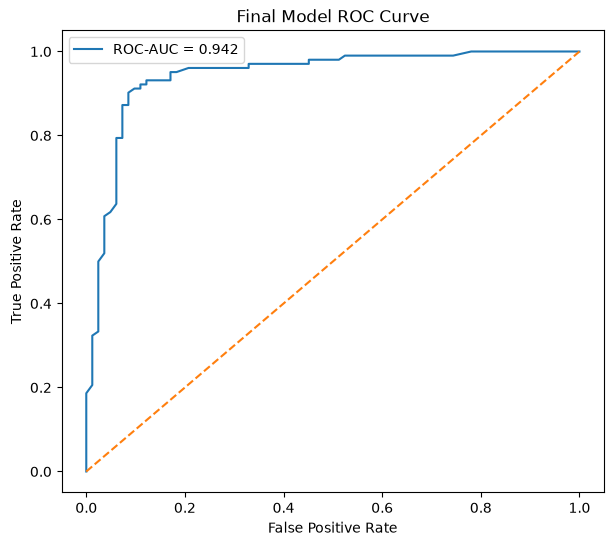

In [63]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    final_test_prob
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {final_res['ROC-AUC']:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Final Model ROC Curve")

plt.legend()
plt.savefig(f"C:/Users/pc/Desktop/inter/Cardiac_Patient_Monitoring/outputs/Final-Model-ROC-Curve.png")

plt.show()

### Chart: Final Model ROC Curve

The ROC curve shows how the classifier behaves across different probability thresholds.

- x-axis = False Positive Rate.
- y-axis = True Positive Rate.
- The dashed diagonal line represents random classification.
- The blue curve represents the final Random Forest.
- The legend reports **ROC-AUC = 0.942**.

### How to interpret the curve

A strong classifier has a curve that stays well above the random diagonal and moves toward the upper-left region.

That is exactly what happens here: the curve rises quickly toward a high True Positive Rate while keeping the False Positive Rate relatively low over a substantial range.

### What ROC-AUC means

ROC-AUC summarizes the model's ability to rank positive cases above negative cases across thresholds.

A value of **0.942** indicates strong discrimination on this test set.

### Why ROC is useful

The confusion matrix uses one classification threshold.

The ROC curve examines the model across many thresholds, giving a broader view of its discrimination ability.

## 14.8 Extract Final Model Feature Importances

In [64]:
final_preprocessor = final_rf_pipeline.named_steps[
    "preprocessor"
]

final_rf_model = final_rf_pipeline.named_steps[
    "classifier"
]

final_feature_names = (
    final_preprocessor
    .get_feature_names_out()
)

final_importances = (
    final_rf_model
    .feature_importances_
)

final_importance_df = pd.DataFrame({
    "Feature": final_feature_names,
    "Importance": final_importances
})

final_importance_df = final_importance_df.sort_values(
    by="Importance",
    ascending=False
)

final_importance_df.head(15)

,Feature,Importance
23,cat__ST_Slope_Up,0.133272
22,cat__ST_Slope_Flat,0.089517
12,cat__ChestPainType_ASY,0.075702
5,num__Oldpeak,0.072791
4,num__MaxHR,0.066193
6,num__Cholesterol_Age_Ratio,0.065871
7,num__MaxHR_Age_Ratio,0.061633
2,num__Cholesterol,0.061536
20,cat__ExerciseAngina_Y,0.051471
8,num__BP_Age_Ratio,0.050831


### What this code does

This extracts feature names and importance values from the **final retrained Random Forest**.

Because the final model uses engineered features, the feature list now contains both original and engineered variables.

The table is sorted from highest to lowest importance and the top 15 are displayed.

### Top final features

The leading features are:

1. `cat__ST_Slope_Up` — **0.1333**
2. `cat__ST_Slope_Flat` — **0.0895**
3. `cat__ChestPainType_ASY` — **0.0757**
4. `num__Oldpeak` — **0.0728**
5. `num__MaxHR` — **0.0662**
6. `num__Cholesterol_Age_Ratio` — **0.0659**
7. `num__MaxHR_Age_Ratio` — **0.0616**
8. `num__Cholesterol` — **0.0615**

### What changed from the original model?

The original Random Forest's strongest feature was also `ST_Slope_Up`, with importance about 0.152.

After final retraining, `ST_Slope_Up` remains the most important feature, but engineered ratio features now appear among the top-ranked variables.

This suggests the engineered features were useful to the final model's internal decision process, even though the earlier validation comparison did not show an improvement over the original feature representation.

### Important caution

Feature importance indicates contribution to the tree model's predictive decisions. It does not prove that a feature causes heart disease.

## 14.9 Chart: Final Model Top 15 Feature Importances

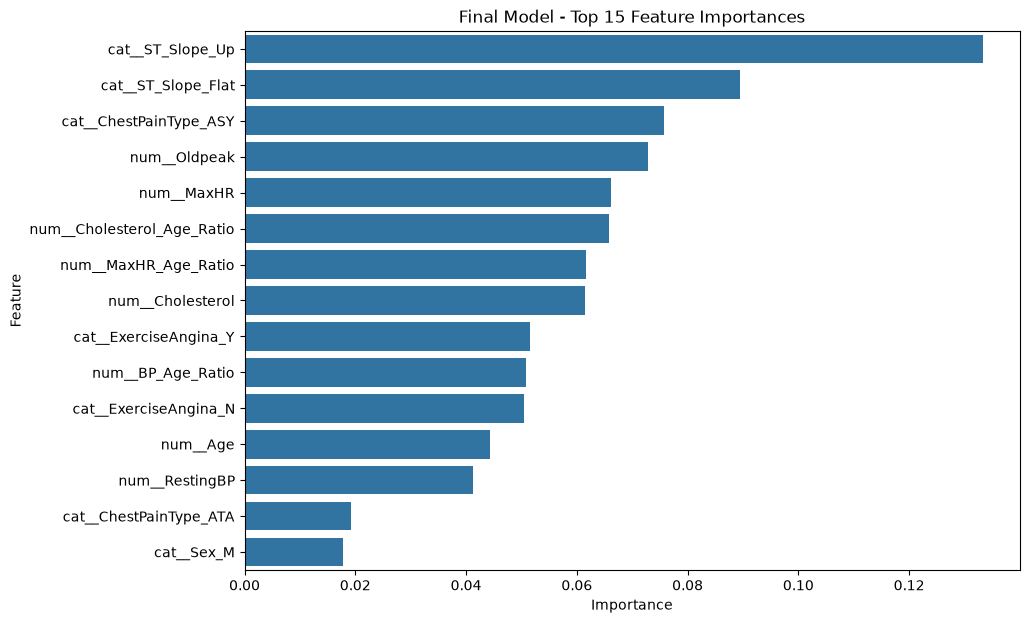

In [65]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=final_importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Final Model - Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.savefig(f"C:/Users/pc/Desktop/inter/Cardiac_Patient_Monitoring/outputs/Final-Model-Top 15-Feature-Importance.png")
plt.show()

### Chart: Final Model Top 15 Feature Importances

This horizontal bar chart ranks the most influential transformed features in the final Random Forest.

### What the chart shows

The largest bar is:

**`cat__ST_Slope_Up` ≈ 0.133**

The next major features include:

- `cat__ST_Slope_Flat` ≈ 0.090
- `cat__ChestPainType_ASY` ≈ 0.076
- `num__Oldpeak` ≈ 0.073
- `num__MaxHR` ≈ 0.066
- `num__Cholesterol_Age_Ratio` ≈ 0.066
- `num__MaxHR_Age_Ratio` ≈ 0.062
- `num__Cholesterol` ≈ 0.062

### Interpretation

The chart shows that both original and engineered variables contribute to the final Random Forest.

ST-slope categories remain especially influential.

The appearance of `Cholesterol_Age_Ratio`, `MaxHR_Age_Ratio`, and `BP_Age_Ratio` among the top features shows that the engineered relationships were used by the final model.

However, importance is not a causal explanation and should not be interpreted as a medical risk ranking.

## 14.10 Final Model Comparison Table

In [66]:
final_compare = pd.DataFrame(
    [
        log_val_res,
        rf_val_res,
        log_engineered_res,
        rf_engineered_res,
        final_res
    ],
    index=[
        "Logistic - Original Validation",
        "Random Forest - Original Validation",
        "Logistic - Engineered Validation",
        "Random Forest - Engineered Validation",
        "Final Model - Test"
    ]
)

final_compare

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic - Original Validation,0.802721,0.802326,0.851852,0.826347,0.904415
Random Forest - Original Validation,0.850340,0.831461,0.913580,0.870588,0.909839
Logistic - Engineered Validation,0.802721,0.809524,0.839506,0.824242,0.901796
Random Forest - Engineered Validation,0.843537,0.829545,0.901235,0.863905,0.908997
Final Model - Test,0.902174,0.896226,0.931373,0.913462,0.942432


### Final Comparison Table

This table places the main experimental results into one view.

| Experiment | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Logistic — Original Validation | 0.803 | 0.802 | 0.852 | 0.826 | 0.904 |
| Random Forest — Original Validation | 0.850 | 0.831 | 0.914 | 0.871 | 0.910 |
| Logistic — Engineered Validation | 0.803 | 0.810 | 0.840 | 0.824 | 0.902 |
| Random Forest — Engineered Validation | 0.844 | 0.830 | 0.901 | 0.864 | 0.909 |
| **Final Model — Test** | **0.902** | **0.896** | **0.931** | **0.913** | **0.942** |

### What the table tells us

**1. Random Forest beats Logistic Regression on the original validation split.**

It improves all five validation metrics.

**2. Feature engineering did not improve validation performance.**

Both engineered models are slightly worse overall than their original counterparts.

**3. The final test result is strong.**

The model actually evaluated on the test set achieves:

- Accuracy = 0.902
- Precision = 0.896
- Recall = 0.931
- F1 = 0.913
- ROC-AUC = 0.942

### Critical interpretation of the final row

The final row is **not the same experiment as the original Random Forest validation row**.

The final code retrains `final_rf_pipeline`, which includes the engineered features, on all development data before testing.

Therefore, the table should be read as:

**validation experiments → model comparison → engineered Random Forest retrained on all development data → final test evaluation**

It should **not** be described as proof that feature engineering improved performance, because the validation comparison showed that engineered features slightly reduced performance.

### Why are the final test scores higher than validation?

There are two major reasons:

1. The final model was retrained using more development observations than the original training split.
2. The validation and test sets contain different observations, so the test set may simply be easier for this particular trained model.

The increase therefore should not be attributed automatically to feature engineering.

### Overall conclusion

The notebook demonstrates strong predictive performance on its held-out test set, but the model-selection narrative should explicitly acknowledge the mismatch between the validation winner and the final engineered model.

## 14.11 Save Model Comparison Results

In [67]:
final_compare.to_csv(
    "../outputs/model_comparison.csv"
)

### What this code does

`to_csv()` saves the final comparison table to:

`../outputs/model_comparison.csv`

### Why save the table?

It makes the experimental results reusable outside the notebook. The saved CSV can be opened in Excel, imported into another analysis, or used in a report.

### Saved content

The file contains the Accuracy, Precision, Recall, F1, and ROC-AUC values for the original, engineered, and final model evaluations.

## 14.12 Save Final Feature Importances

In [68]:
final_importance_df.to_csv(
    "../outputs/feature_importance.csv",
    index=False
)

### What this code does

This saves `final_importance_df` to:

`../outputs/feature_importance.csv`

`index=False` prevents pandas from adding the DataFrame index as an unnecessary extra column.

### Why save feature importance?

The resulting CSV provides a clean list of transformed features and their Random Forest importance values for later reporting or visualization.

## 14.13 Save the Final Trained Model

In [69]:
import joblib

joblib.dump(
    final_rf_pipeline,
    "../models/final_model.pkl"
)

['../models/final_model.pkl']

### What this code does

`joblib.dump()` serializes the complete trained `final_rf_pipeline` and saves it as:

`../models/final_model.pkl`

### Why save the whole pipeline?

The saved object contains the preprocessing and classifier together.

That is important because a future prediction must apply the exact same:

- numerical imputation,
- scaling,
- categorical encoding,
- engineered-feature preparation expected by the pipeline,
- and Random Forest model.

Saving the complete pipeline reduces the risk of applying preprocessing differently later.

### Final project output

The trained model is exported as `final_model.pkl`, while the main evaluation and feature-importance tables are exported as CSV files.

## 13. Key Findings

The exploratory analysis identified several numerical and categorical patterns in the synthetic heart-disease dataset.

The target contains 508 positive cases and 410 negative cases, corresponding to approximately 55.3% and 44.7%.

The numerical analysis showed that MaxHR had the strongest negative linear correlation with the target, while Oldpeak had the strongest positive linear correlation among the numerical predictors.

The original supervised-learning comparison favored Random Forest over Logistic Regression on the validation set and on most cross-validation metrics.

Feature engineering was explicitly tested, but it did **not** improve validation performance for either model. In fact, the engineered Random Forest was slightly worse than the original Random Forest on all five validation metrics.

An important methodological point is that the final code nevertheless retrains and evaluates the **engineered Random Forest** on the test set. Therefore, the final test results describe the engineered Random Forest, not the original Random Forest that performed best in the validation comparison.

The final test evaluation produced Accuracy = 0.902, Precision = 0.896, Recall = 0.931, F1 = 0.913, and ROC-AUC = 0.942.

## 14. Limitations

This dataset is synthetic and therefore does not represent real clinical patient data.

The developed model is intended for educational machine-learning purposes and must not be interpreted as a clinical diagnostic system.

Several numerical variables contain unusual values in the dataset, including zeros for measurements where zero may be unrealistic in a real clinical setting. These values can affect distributions, correlations, feature importance, and model behavior.

The categorical variables are also not perfectly balanced, with some categories much more frequent than others.

Model performance depends on the quality, structure, and assumptions of this dataset.

The final test set contains only 184 observations, so its metrics should not be treated as universally representative of future data.

Most importantly, the notebook's validation comparison favors the original Random Forest, while the final code evaluates the engineered Random Forest. This means the model-selection narrative should be presented carefully.

Further validation on independent real-world datasets would be required before considering any real-world medical application.

## 15. Conclusion

This project developed a complete supervised machine-learning workflow for binary heart-disease classification using synthetic cardiovascular and health-related data.

The workflow included:

- data loading and inspection,
- data cleaning,
- descriptive statistics,
- exploratory visual analysis,
- correlation analysis,
- train/validation/test splitting,
- preprocessing,
- Logistic Regression,
- Random Forest,
- cross-validation,
- feature analysis,
- feature engineering,
- model comparison,
- final test evaluation,
- error analysis,
- and export of the trained model and results.

Random Forest was the strongest model in the original validation and cross-validation comparisons.

Feature engineering was also tested, but the engineered versions did not improve validation performance.

The final code then retrained the engineered Random Forest on all development data and evaluated it on the untouched test set. That final test evaluation achieved **90.2% Accuracy, 89.6% Precision, 93.1% Recall, 91.3% F1-score, and 94.2% ROC-AUC**.

The most important lesson from the experiment is that a larger or more engineered feature set does not automatically produce better validation performance. Model selection should be based on measured evidence, and the distinction between validation performance and final test performance must remain clear.

Because the dataset is synthetic and the model is not clinically validated, these results demonstrate a machine-learning methodology rather than a medical diagnostic capability.